# Factor-Based Return Attribution using Fama-French Multi-Factor Regression on NSE Stocks

#### Author: Sohom Halder | MS Statistics | IIT Kanpur

## Project Overview
This project applies the Fama-French multi-factor framework to eight NSE large-cap stocks, moving from a CAPM single-factor baseline through the three-factor (Market, SMB, HML) model to a four-factor comparison. The goal is to attribute realized stock returns to systematic risk exposure versus stock-specific alpha, and to test whether the standard OLS assumptions actually hold for Indian equity return data.

**Universe:** Reliance, HDFC Bank, Infosys, Sun Pharma, Tata Steel, Maruti Suzuki, ITC, Bharti Airtel

**Period:** January 2015 – December 2025 (monthly)

**Stock Price Data:** Yahoo Finance (yfinance)

**Factor Data:** Market, SMB, HML, and WML monthly factor returns from the Fama-French and Momentum Factor library for the Indian market, maintained by IIM Ahmedabad (Agarwalla, Jacob & Varma, 2013), built on CMIE Prowess data with survivorship-bias correction. Sourced from the [IIMA Faculty webpage / data library link].

## Project Structure
1. [Data Collection and Preparation](#phase-1-data-collection-and-preparation)
2. [Factor Construction (Market, SMB, HML)](#phase-2-factor-construction-market-smb-hml)
3. [CAPM Baseline Regression](#phase-3-capm-baseline-regression)
4. [Fama-French 3-Factor Model](#phase-4-fama-french-3-factor-model)
5. [Regression Assumption Testing (VIF, White, Durbin-Watson, Jarque-Bera, Newey-West)](#phase-5-regression-assumption-testing)
6. [Rolling Window Regression](#phase-6-rolling-window-regression)
7. [CAPM vs FF3 vs Carhart Four-Factor Model Comparison](#phase-7-capm-vs-ff3-vs-carhart-four-factor-model-comparison)
8. [Final Dashboard](#phase-8-final-dashboard)

## Phase 1: Data Collection and Preparation

Before any factor modelling can happen, I need clean, correctly-aligned price data for the eight stocks in this portfolio. This phase pulls daily prices via yfinance, checks them for gaps, resamples down to monthly frequency (the standard convention for Fama-French style regressions), and computes simple monthly returns for each stock.

In [1]:
# Cell 1 — Phase 1: Data Collection and Preparation | Import Libraries & Setup

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("Environment ready")

Environment ready


### Define Universe & Download Price Data

Sets up the environment — pandas, numpy, statsmodels for the regressions, matplotlib/seaborn for plotting, and yfinance for the price data. Nothing to interpret here beyond confirming the imports ran cleanly.

In [2]:
# Cell 2 — Phase 1: Data Collection and Preparation | Define Universe & Download Price Data
# NSE tickers carry a .NS suffix on Yahoo Finance

tickers = {
    'RELIANCE.NS': 'Reliance',
    'HDFCBANK.NS': 'HDFC Bank',
    'INFY.NS': 'Infosys',
    'SUNPHARMA.NS': 'Sun Pharma',
    'TATASTEEL.NS': 'Tata Steel',
    'MARUTI.NS': 'Maruti Suzuki',
    'ITC.NS': 'ITC',
    'BHARTIARTL.NS': 'Bharti Airtel'
}

start_date = '2015-01-01'
end_date = '2026-01-01'  # yfinance end date is exclusive, so this pulls all of Dec 2025

raw_data = yf.download(list(tickers.keys()), start=start_date, end=end_date, auto_adjust=True, progress=False)

print(raw_data.shape)
raw_data.head()

(2716, 40)


Price              Close                                                      \
Ticker     BHARTIARTL.NS HDFCBANK.NS  INFY.NS   ITC.NS MARUTI.NS RELIANCE.NS   
Date                                                                           
2015-01-01      308.0735    213.7009 359.9811 156.9481 3032.0349    189.1254   
2015-01-02      309.8987    216.6750 367.0552 157.4397 3049.1433    188.6248   
2015-01-05      303.0225    214.8456 363.9009 158.0595 3129.1929    186.5587   
2015-01-06      300.6455    211.5011 356.2981 153.9984 3081.4985    178.0918   
2015-01-07      301.3671    212.1184 358.0028 151.1344 3120.0713    181.9685   

Price                                         High              ...  \
Ticker     SUNPHARMA.NS TATASTEEL.NS BHARTIARTL.NS HDFCBANK.NS  ...   
Date                                                            ...   
2015-01-01     750.9713      28.3141      309.7714    214.2283  ...   
2015-01-02     754.6705      28.7551      311.5541    217.5729  ...   
2015-01-05     755.1273      29.1717      310.9175    217.8534  ...   
2015-01-06     738.5038      27.7576      302.3009    214.7109  ...   
2015-01-07     739.6455      27.2255      303.9139    213.5437  ...   

Price              Open                     Volume                       \
Ticker     SUNPHARMA.NS TATASTEEL.NS BHARTIARTL.NS HDFCBANK.NS  INFY.NS   
Date                                                                      
2015-01-01     754.8988      27.7996       2460188     3544940  2002764   
2015-01-02     752.6155      28.4226       2795887     5900384  6778320   
2015-01-05     754.5336      28.9127       1605267     4796000  9937024   
2015-01-06     751.7020      28.9827       3916948     8219680  9667316   
2015-01-07     739.0061      27.8486       4899318     5746112  7249916   

Price                                                                 
Ticker        ITC.NS MARUTI.NS RELIANCE.NS SUNPHARMA.NS TATASTEEL.NS  
Date                                                                  
2015-01-01   2636761    299232     2963643       587479     26570816  
2015-01-02   6853849    233924     7331366       710310     36043328  
2015-01-05   8556295    536747    10103941       792287     54638866  
2015-01-06  13597291    422743    18627980      1709888     64767961  
2015-01-07  12421217    369241    20720312      1730518     49846923  

[5 rows x 40 columns]

### Extract Close Prices & Rename Columns

Downloads daily OHLCV data for all eight NSE tickers from Yahoo Finance in a single call, covering the full study window. yfinance returns tickers in alphabetical order rather than the order they were passed in, and nests everything under a two-level column structure (price field, then ticker) — both handled explicitly in the next cell rather than assumed.

In [3]:
# Cell 3 — Phase 1: Data Collection and Preparation | Extract Close Prices & Rename Columns

close_prices = raw_data['Close'].copy()
close_prices = close_prices.rename(columns=tickers)
close_prices = close_prices[list(tickers.values())]  # reorder to match our original stock order

print(close_prices.shape)
close_prices.head()

(2716, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-01-01,189.1254,213.7009,359.9811,750.9713,28.3141,3032.0349,156.9481,308.0735
2015-01-02,188.6248,216.6750,367.0552,754.6705,28.7551,3049.1433,157.4397,309.8987
2015-01-05,186.5587,214.8456,363.9009,755.1273,29.1717,3129.1929,158.0595,303.0225
2015-01-06,178.0918,211.5011,356.2981,738.5038,27.7576,3081.4985,153.9984,300.6455
2015-01-07,181.9685,212.1184,358.0028,739.6455,27.2255,3120.0713,151.1344,301.3671


### Check for Missing Values

Pulls just the Close price field out of the raw download, renames the tickers to readable company names, and reorders the columns back to the original stock order (since yfinance returned them alphabetically). This is the clean price panel every later phase builds on.

In [4]:
# Cell 4 — Phase 1: Data Collection and Preparation | Check for Missing Values

print(close_prices.isnull().sum())
print("\nTotal missing values:", close_prices.isnull().sum().sum())
print("\nDate range:", close_prices.index.min().date(), "to", close_prices.index.max().date())
print("Trading days:", len(close_prices))

Ticker
Reliance         0
HDFC Bank        0
Infosys          0
Sun Pharma       0
Tata Steel       0
Maruti Suzuki    0
ITC              0
Bharti Airtel    0
dtype: int64

Total missing values: 0

Date range: 2015-01-01 to 2025-12-31
Trading days: 2716


### Resample to Monthly & Compute Returns

Checks for missing values across all eight stocks and confirms the date range and row count. Zero missing values across the board — yfinance only returns rows for actual NSE trading days, so a clean result here means there's no silent gap-filling happening.

In [5]:
# Cell 5 — Phase 1: Data Collection and Preparation | Resample to Monthly & Compute Returns

monthly_prices = close_prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()

print("Monthly prices shape:", monthly_prices.shape)
print("Monthly returns shape:", monthly_returns.shape)
monthly_returns.head()

Monthly prices shape: (132, 8)
Monthly returns shape: (131, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-02-28,-0.0652,-0.0217,0.0578,-0.0423,-0.1019,-0.0118,0.0682,-0.0495
2015-03-31,-0.0345,-0.0297,-0.0209,0.1650,-0.0967,0.0258,-0.1723,0.1073
2015-04-30,0.0440,-0.0331,-0.1245,-0.0831,0.1376,0.0077,-0.0107,-0.0310
2015-05-31,0.0298,0.0624,0.0417,0.0290,-0.0884,0.0161,0.0147,0.1168
2015-06-30,0.1404,0.0158,-0.0122,-0.0947,-0.0728,0.0628,-0.0165,-0.0130


### Summary Statistics & Sanity Check

Resamples the daily price panel down to month-end prices and computes simple (not log) monthly returns via `.pct_change()`. Simple returns are a deliberate choice, not log returns — the IIMA factor data used in Phase 2 is expressed as holding-period returns, and mixing log stock returns with simple-return factors would be an inconsistent regression setup. Returns start in February 2015 since January has no prior month to compute a return against.

,Ann. Mean Return,Ann. Volatility,Skewness,Excess Kurtosis,Min (Monthly),Max (Monthly)
Ticker,,,,,,
Reliance,0.2262,0.2676,0.6896,1.3593,-0.1617,0.3163
HDFC Bank,0.1496,0.2052,-0.3460,3.8619,-0.2681,0.2174
Infosys,0.1571,0.2414,0.4219,2.0771,-0.1779,0.3126
Sun Pharma,0.1040,0.2817,0.3039,0.8883,-0.2186,0.3183
Tata Steel,0.2363,0.3635,0.2720,1.1248,-0.2938,0.4063
Maruti Suzuki,0.1884,0.2768,-0.6160,2.3236,-0.3175,0.2496
ITC,0.1042,0.2121,-0.0120,0.6437,-0.1723,0.1719
Bharti Airtel,0.2060,0.2526,0.0014,1.1067,-0.1796,0.2767


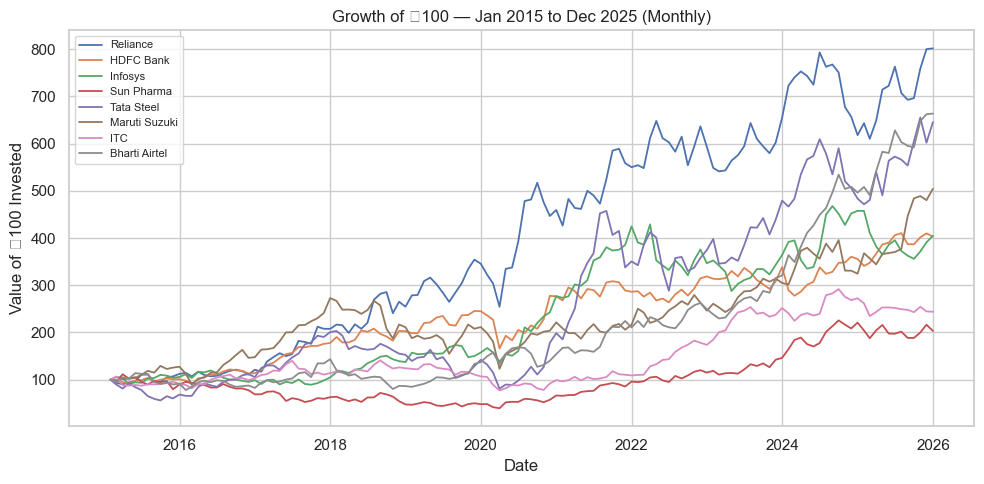

In [6]:
# Cell 6 — Phase 1: Data Collection and Preparation | Summary Statistics & Sanity Check

from IPython.display import display

summary_stats = pd.DataFrame({
    'Ann. Mean Return': monthly_returns.mean() * 12,
    'Ann. Volatility': monthly_returns.std() * np.sqrt(12),
    'Skewness': monthly_returns.skew(),
    'Excess Kurtosis': monthly_returns.kurt(),
    'Min (Monthly)': monthly_returns.min(),
    'Max (Monthly)': monthly_returns.max()
})
display(summary_stats)

growth = monthly_prices / monthly_prices.iloc[0] * 100

plt.figure(figsize=(10, 5))
for stock in growth.columns:
    plt.plot(growth.index, growth[stock], label=stock, linewidth=1.3)
plt.title('Growth of ₹100 — Jan 2015 to Dec 2025 (Monthly)')
plt.xlabel('Date')
plt.ylabel('Value of ₹100 Invested')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Closes out Phase 1 with descriptive statistics (annualized return/vol, skew, kurtosis) and a growth-of-₹100 chart for all eight stocks. Tata Steel carries the highest volatility (~36% annualized) as the portfolio's cyclical, Sun Pharma shows the weakest returns, and Reliance shows the strongest cumulative growth over the decade — a sensible, recognizable spread for this set of large-caps.

## Phase 2: Factor Construction (Market, SMB, HML)

Genuine SMB and HML factors require market-cap and book-to-market sorts across a broad universe of stocks, redone every period — not something a free tool like yfinance can reconstruct reliably or without look-ahead bias. Instead of approximating this, I sourced the Market premium, SMB, and HML series from the Fama-French and Momentum factor data library maintained by IIM Ahmedabad (Agarwalla, Jacob & Varma, 2013), built on CMIE Prowess data with survivorship-bias correction. This phase loads that file, aligns it to the study window (Feb 2015 – Dec 2025), and merges it with the stock returns to compute excess returns — the dependent variable used in every regression from here on.

In [7]:
# Cell 7 — Phase 2: Factor Construction | Load IIMA Factor Data

factor_file = '2025-12_FourFactors_and_Market_Returns_Monthly_SurvivorshipBiasAdjusted.csv'

factors_raw = pd.read_csv(factor_file, na_values=['NA'])
factors_raw['Date'] = pd.to_datetime(factors_raw['Date'], format='%Y-%m') + pd.offsets.MonthEnd(0)
factors_raw = factors_raw.set_index('Date')

print(factors_raw.shape)
print(factors_raw.isnull().sum())
factors_raw.tail()

(387, 5)
SMB    1
HML    1
WML    1
MF     1
RF     1
dtype: int64


,SMB,HML,WML,MF,RF
Date,,,,,
2025-08-31,-1.5922,-2.3819,0.5409,-1.8000,0.4232
2025-09-30,-2.8250,3.4737,-2.7506,0.5306,0.4701
2025-10-31,-2.1472,1.5348,1.8486,2.8881,0.4516
2025-11-30,-3.6742,-1.7667,4.9391,-1.0032,0.4057
2025-12-31,-3.6219,1.8529,1.3014,-0.7207,0.4677


### Filter to Study Window & Convert to Decimal

Loads the raw IIMA factor CSV and parses the monthly date index. The file covers October 1993 through December 2025 (387 monthly rows), with a single missing value in each factor column, both traced to the early-1990s rows — well outside this project's study window, so they fall away naturally in the next step.

In [8]:
# Cell 8 — Phase 2: Factor Construction | Filter to Study Window & Convert to Decimal

factors = factors_raw.loc['2015-02':'2025-12'] / 100

print(factors.shape)
print(factors.isnull().sum())
factors.head()

(131, 5)
SMB    0
HML    0
WML    0
MF     0
RF     0
dtype: int64


,SMB,HML,WML,MF,RF
Date,,,,,
2015-02-28,-0.0031,0.0010,0.0101,0.0053,0.0063
2015-03-31,0.0025,-0.0595,0.0862,-0.0243,0.0068
2015-04-30,0.0174,0.0299,-0.0553,-0.0363,0.0063
2015-05-31,0.0059,-0.0425,0.0348,0.0309,0.0061
2015-06-30,-0.0177,-0.0090,0.0369,-0.0166,0.0065


### Merge Stock Returns with Factors & Compute Excess Returns

Trims the factor data to the study window (Feb 2015 – Dec 2025) and converts values from percentage-point form to decimal, matching the scale of the stock returns from Phase 1. This step matters more than it looks — a scale mismatch here would silently distort every beta estimate downstream without throwing an error.

In [9]:
# Cell 9 — Phase 2: Factor Construction | Merge Stock Returns with Factors & Compute Excess Returns

# Confirm both datasets share the exact same date index before merging
assert monthly_returns.index.equals(factors.index), "Date mismatch between stock returns and factor data"

excess_returns = monthly_returns.sub(factors['RF'], axis=0)

print(excess_returns.shape)
excess_returns.head()

(131, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-02-28,-0.0716,-0.0280,0.0515,-0.0487,-0.1083,-0.0181,0.0619,-0.0559
2015-03-31,-0.0413,-0.0365,-0.0277,0.1582,-0.1035,0.0190,-0.1791,0.1005
2015-04-30,0.0377,-0.0394,-0.1308,-0.0894,0.1313,0.0014,-0.0170,-0.0373
2015-05-31,0.0237,0.0564,0.0356,0.0229,-0.0945,0.0100,0.0087,0.1107
2015-06-30,0.1338,0.0093,-0.0187,-0.1012,-0.0793,0.0562,-0.0230,-0.0196


### Factor Summary Statistics & Correlation Check

Merges the stock returns with the risk-free rate to compute excess returns (Ri − Rf) — the actual dependent variable used in every regression from here forward. An explicit assertion checks that both datasets share the exact same date index before subtracting, since a silent misalignment here is the kind of bug that's easy to miss and hard to trace once it's baked into every later result.

,Ann. Mean,Ann. Volatility,Skewness,Excess Kurtosis,Min (Monthly),Max (Monthly)
MF,0.0867,0.1596,-0.5836,1.9289,-0.1881,0.1388
SMB,-0.0065,0.1452,-0.1444,0.5893,-0.1409,0.0922
HML,0.1060,0.1584,0.2971,0.0908,-0.0968,0.1361



Factor Correlation Matrix:


,MF,SMB,HML
MF,1.0000,0.3681,0.4796
SMB,0.3681,1.0000,0.2589
HML,0.4796,0.2589,1.0000


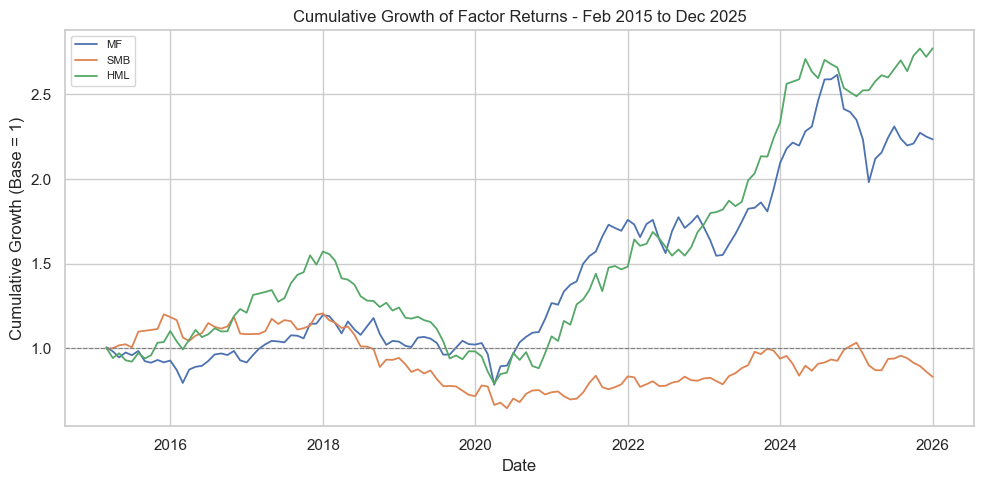

In [10]:
# Cell 10 — Phase 2: Factor Construction | Factor Summary Statistics & Correlation Check

factor_cols = ['MF', 'SMB', 'HML']

factor_stats = pd.DataFrame({
    'Ann. Mean': factors[factor_cols].mean() * 12,
    'Ann. Volatility': factors[factor_cols].std() * np.sqrt(12),
    'Skewness': factors[factor_cols].skew(),
    'Excess Kurtosis': factors[factor_cols].kurt(),
    'Min (Monthly)': factors[factor_cols].min(),
    'Max (Monthly)': factors[factor_cols].max()
})
display(factor_stats)

print("\nFactor Correlation Matrix:")
display(factors[factor_cols].corr())

cumulative_factors = (1 + factors[factor_cols]).cumprod()

plt.figure(figsize=(10, 5))
for col in factor_cols:
    plt.plot(cumulative_factors.index, cumulative_factors[col], label=col, linewidth=1.3)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.title('Cumulative Growth of Factor Returns - Feb 2015 to Dec 2025')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (Base = 1)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Closes Phase 2 with summary statistics and a correlation check on the three raw factors, plus a cumulative growth chart. The market premium (8.7% annualized) and HML (10.6%) both trend upward over the decade with a visible dip in Market around the COVID period; SMB is essentially flat, consistent with large-caps outperforming small-caps in India over this stretch. Market and HML correlate at 0.48 — worth flagging early since it resurfaces as the multicollinearity check in Phase 5.

## Phase 3: CAPM Baseline Regression

Before layering on size and value, I start with the simplest asset pricing model — CAPM — regressing each stock's excess return on just the market premium. This gives a baseline beta and R² for every stock and sets up the comparison point for Phase 4 and Phase 7.

In [11]:
# Cell 11 — Phase 3: CAPM Baseline Regression | Run CAPM for All Stocks

capm_models = {}
capm_results = []

X = sm.add_constant(factors['MF'])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    capm_models[stock] = model

    capm_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha t-stat': model.tvalues['const'],
        'Alpha p-value': model.pvalues['const'],
        'Beta': model.params['MF'],
        'Beta t-stat': model.tvalues['MF'],
        'Beta p-value': model.pvalues['MF'],
        'R-squared': model.rsquared
    })

capm_summary = pd.DataFrame(capm_results).set_index('Stock')
display(capm_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha t-stat,Alpha p-value,Beta,Beta t-stat,Beta p-value,R-squared
Stock,,,,,,,,
Reliance,0.0064,0.0773,1.2104,0.2283,1.0623,9.2763,0.0000,0.4001
HDFC Bank,0.0022,0.0268,0.5250,0.6005,0.7603,8.3023,0.0000,0.3482
Infosys,0.0038,0.0460,0.6788,0.4985,0.6252,5.1437,0.0000,0.1702
Sun Pharma,-0.0015,-0.0181,-0.2298,0.8186,0.7519,5.3324,0.0000,0.1806
Tata Steel,0.0060,0.0720,0.7651,0.4456,1.2391,7.3372,0.0000,0.2944
Maruti Suzuki,0.0043,0.0520,0.7197,0.4730,0.9171,7.0707,0.0000,0.2793
ITC,-0.0012,-0.0144,-0.2620,0.7937,0.7130,7.2083,0.0000,0.2871
Bharti Airtel,0.0067,0.0799,1.1896,0.2364,0.7996,6.6403,0.0000,0.2547


### Beta & R-squared Visualization

Runs a separate CAPM regression for each of the eight stocks. Every beta comes back positive and statistically significant (p < 0.0001), ranging from 0.63 (Infosys) to 1.24 (Tata Steel), and none of the eight alphas is statistically distinguishable from zero — exactly what a working CAPM should show over a full decade. R² averages 0.28, meaning the single market factor leaves most of each stock's return variation unexplained, which is the motivation for Phase 4.

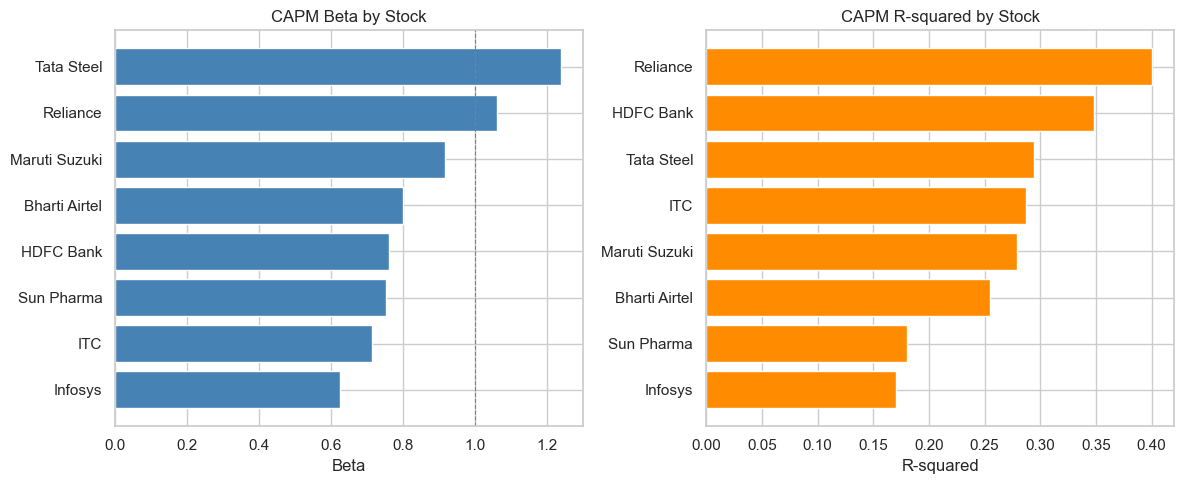

Average Beta across portfolio: 0.8586
Average R-squared across portfolio: 0.2769

Highest Beta: Tata Steel (1.2391)
Lowest Beta: Infosys (0.6252)


In [12]:
# Cell 12 — Phase 3: CAPM Baseline Regression | Beta & R-squared Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sorted_beta = capm_summary['Beta'].sort_values()
axes[0].barh(sorted_beta.index, sorted_beta.values, color='steelblue')
axes[0].axvline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('CAPM Beta by Stock')
axes[0].set_xlabel('Beta')

sorted_r2 = capm_summary['R-squared'].sort_values()
axes[1].barh(sorted_r2.index, sorted_r2.values, color='darkorange')
axes[1].set_title('CAPM R-squared by Stock')
axes[1].set_xlabel('R-squared')

plt.tight_layout()
plt.show()

print(f"Average Beta across portfolio: {capm_summary['Beta'].mean():.4f}")
print(f"Average R-squared across portfolio: {capm_summary['R-squared'].mean():.4f}")
print(f"\nHighest Beta: {capm_summary['Beta'].idxmax()} ({capm_summary['Beta'].max():.4f})")
print(f"Lowest Beta: {capm_summary['Beta'].idxmin()} ({capm_summary['Beta'].min():.4f})")

Visualizes the CAPM betas and R² from the table above. Tata Steel and Reliance are the only stocks with beta above 1 (amplifying market moves), while Reliance's R² (0.40) is the highest in the portfolio — sensible given it's the single largest weight in the Nifty index.

## Phase 4: Fama-French 3-Factor Model

Here I extend CAPM by adding SMB and HML, testing whether size and value exposure explain any of the return variation that CAPM's single market factor leaves on the table. Since FF3 nests CAPM, R² can only increase — the real question is by how much, and for which stocks.

In [13]:
# Cell 13 — Phase 4: Fama-French 3-Factor Model | Run FF3 for All Stocks

ff3_models = {}
ff3_results = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    ff3_models[stock] = model

    ff3_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha p-value': model.pvalues['const'],
        'Beta (Mkt)': model.params['MF'],
        'Beta (SMB)': model.params['SMB'],
        'Beta (HML)': model.params['HML'],
        'SMB p-value': model.pvalues['SMB'],
        'HML p-value': model.pvalues['HML'],
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj
    })

ff3_summary = pd.DataFrame(ff3_results).set_index('Stock')
display(ff3_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha p-value,Beta (Mkt),Beta (SMB),Beta (HML),SMB p-value,HML p-value,R-squared,Adj. R-squared
Stock,,,,,,,,,,
Reliance,0.0053,0.0639,0.3046,1.2430,-0.4681,-0.0500,0.0005,0.6939,0.4577,0.4449
HDFC Bank,0.0020,0.0242,0.6422,0.7886,-0.0793,-0.0036,0.4699,0.9729,0.3510,0.3357
Infosys,0.0059,0.0705,0.2921,0.8459,-0.0685,-0.4154,0.6255,0.0028,0.2305,0.2123
Sun Pharma,-0.0034,-0.0408,0.6033,0.8248,-0.4024,0.1302,0.0160,0.4178,0.2193,0.2008
Tata Steel,-0.0008,-0.0094,0.9114,1.0158,-0.6294,0.9122,0.0006,0.0000,0.4535,0.4406
Maruti Suzuki,0.0043,0.0511,0.4891,0.8598,0.0845,0.0609,0.5863,0.6867,0.2822,0.2652
ITC,-0.0019,-0.0228,0.6835,0.7569,-0.1766,0.0320,0.1349,0.7797,0.2997,0.2832
Bharti Airtel,0.0047,0.0559,0.4047,0.8106,-0.3139,0.1980,0.0273,0.1498,0.2910,0.2743


### Factor Loadings & Explanatory Power Gain

Extends CAPM with SMB and HML for all eight stocks. R² increases for every stock versus CAPM — not a coincidence to verify, it's mathematically guaranteed since CAPM is nested inside FF3. SMB comes back negative for 7 of 8 stocks, consistent with a large/mega-cap portfolio loading negatively on a size factor defined as small-minus-big. HML splits cleanly along growth/value lines: significantly negative for Infosys (−0.42, the classic growth-stock signature) and significantly positive for Tata Steel (+0.91, the commodity/value signature).

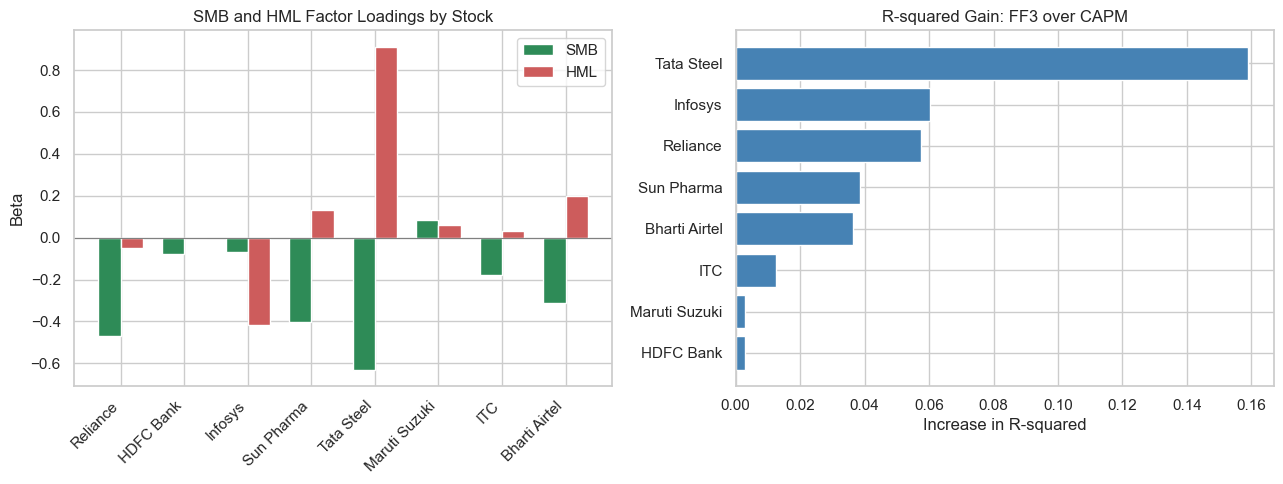

Average R-squared gain from adding SMB and HML: 0.0463

Stocks with significant SMB exposure (p < 0.05):
['Reliance', 'Sun Pharma', 'Tata Steel', 'Bharti Airtel']

Stocks with significant HML exposure (p < 0.05):
['Infosys', 'Tata Steel']


In [14]:
# Cell 14 — Phase 4: Fama-French 3-Factor Model | Factor Loadings & Explanatory Power Gain

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(ff3_summary.index))
width = 0.35

axes[0].bar(x - width/2, ff3_summary['Beta (SMB)'], width, label='SMB', color='seagreen')
axes[0].bar(x + width/2, ff3_summary['Beta (HML)'], width, label='HML', color='indianred')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ff3_summary.index, rotation=45, ha='right')
axes[0].set_title('SMB and HML Factor Loadings by Stock')
axes[0].set_ylabel('Beta')
axes[0].legend()

r2_gain = (ff3_summary['R-squared'] - capm_summary['R-squared']).sort_values()
axes[1].barh(r2_gain.index, r2_gain.values, color='steelblue')
axes[1].set_title('R-squared Gain: FF3 over CAPM')
axes[1].set_xlabel('Increase in R-squared')

plt.tight_layout()
plt.show()

print("Average R-squared gain from adding SMB and HML:", round(r2_gain.mean(), 4))
print("\nStocks with significant SMB exposure (p < 0.05):")
print(ff3_summary[ff3_summary['SMB p-value'] < 0.05].index.tolist())
print("\nStocks with significant HML exposure (p < 0.05):")
print(ff3_summary[ff3_summary['HML p-value'] < 0.05].index.tolist())

Visualizes the SMB/HML loadings and the R² gain from adding them. Tata Steel shows the largest R² improvement over CAPM (+0.16), consistent with its strong, significant loadings on both factors; HDFC Bank and Maruti Suzuki barely move, meaning size and value add almost nothing for those two names specifically.

## Phase 5: Regression Assumption Testing

Running an OLS regression and reporting the coefficients isn't enough — OLS relies on assumptions (no multicollinearity, constant error variance, no autocorrelation, normally distributed residuals) that need to actually be checked, not assumed. This phase runs five diagnostics on the FF3 model: VIF for multicollinearity, White's test for heteroskedasticity, Durbin-Watson for autocorrelation, Jarque-Bera for residual normality, and finally Newey-West HAC standard errors to correct for whatever violations turn up.

In [15]:
# Cell 15 — Phase 5: Regression Assumption Testing | VIF - Multicollinearity Check

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(factors[['MF', 'SMB', 'HML']])

vif_data = pd.DataFrame({
    'Factor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_data = vif_data[vif_data['Factor'] != 'const'].reset_index(drop=True)
display(vif_data)

,Factor,VIF
0,MF,1.4161
1,SMB,1.1687
2,HML,1.3121


### White's Test for Heteroskedasticity

Checks the three factors for multicollinearity. All three VIF values (Market 1.42, SMB 1.17, HML 1.31) sit comfortably below the standard danger threshold of 5 — the 0.48 Market–HML correlation flagged in Phase 2 is real but nowhere near severe enough to distort the coefficient estimates.

In [16]:
# Cell 16 — Phase 5: Regression Assumption Testing | White's Test for Heteroskedasticity

from statsmodels.stats.diagnostic import het_white

white_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

    white_results.append({
        'Stock': stock,
        'LM Statistic': lm_stat,
        'LM p-value': lm_pvalue,
        'F Statistic': f_stat,
        'F p-value': f_pvalue,
        'Heteroskedastic (5%)': 'Yes' if lm_pvalue < 0.05 else 'No'
    })

white_summary = pd.DataFrame(white_results).set_index('Stock')
display(white_summary.round(4))

,LM Statistic,LM p-value,F Statistic,F p-value,Heteroskedastic (5%)
Stock,,,,,
Reliance,25.8127,0.0022,3.2992,0.0012,Yes
HDFC Bank,22.3289,0.0079,2.7625,0.0057,Yes
Infosys,13.5197,0.1405,1.5472,0.1391,No
Sun Pharma,13.7165,0.1328,1.5723,0.1310,No
Tata Steel,18.4483,0.0303,2.2037,0.0262,Yes
Maruti Suzuki,23.3429,0.0055,2.9151,0.0037,Yes
ITC,17.0615,0.0478,2.0132,0.0433,Yes
Bharti Airtel,11.2468,0.2592,1.2627,0.2642,No


### Durbin-Watson Test for Autocorrelation

Tests each stock's FF3 residuals for heteroskedasticity. Five of the eight stocks fail (Reliance, HDFC Bank, Tata Steel, Maruti Suzuki, ITC) — a realistic result for a decade of monthly equity data that includes the COVID shock, and the direct justification for applying Newey-West correction later in this phase.

In [17]:
# Cell 17 — Phase 5: Regression Assumption Testing | Durbin-Watson Test for Autocorrelation

from statsmodels.stats.stattools import durbin_watson

dw_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    dw_stat = durbin_watson(model.resid)

    if dw_stat < 1.5:
        flag = 'Positive Autocorrelation'
    elif dw_stat > 2.5:
        flag = 'Negative Autocorrelation'
    else:
        flag = 'No Strong Autocorrelation'

    dw_results.append({
        'Stock': stock,
        'Durbin-Watson': dw_stat,
        'Flag': flag
    })

dw_summary = pd.DataFrame(dw_results).set_index('Stock')
display(dw_summary.round(4))

,Durbin-Watson,Flag
Stock,,
Reliance,2.0546,No Strong Autocorrelation
HDFC Bank,2.2669,No Strong Autocorrelation
Infosys,1.8317,No Strong Autocorrelation
Sun Pharma,2.2182,No Strong Autocorrelation
Tata Steel,1.9760,No Strong Autocorrelation
Maruti Suzuki,1.9507,No Strong Autocorrelation
ITC,1.9253,No Strong Autocorrelation
Bharti Airtel,2.0071,No Strong Autocorrelation


### Jarque-Bera Test for Residual Normality

Tests for autocorrelation in the FF3 residuals. Every stock lands in a tight 1.83–2.27 band around the neutral value of 2, meaning autocorrelation isn't a real problem here at monthly frequency — a cleaner result than heteroskedasticity, and consistent with autocorrelation being more of a daily-frequency issue that monthly aggregation smooths away.

In [18]:
# Cell 18 — Phase 5: Regression Assumption Testing | Jarque-Bera Test for Residual Normality

from statsmodels.stats.stattools import jarque_bera

jb_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)

    jb_results.append({
        'Stock': stock,
        'JB Statistic': jb_stat,
        'JB p-value': jb_pvalue,
        'Skewness': skew,
        'Kurtosis': kurtosis,
        'Normal Residuals (5%)': 'Yes' if jb_pvalue >= 0.05 else 'No'
    })

jb_summary = pd.DataFrame(jb_results).set_index('Stock')
display(jb_summary.round(4))

,JB Statistic,JB p-value,Skewness,Kurtosis,Normal Residuals (5%)
Stock,,,,,
Reliance,2.1326,0.3443,0.2582,3.3523,Yes
HDFC Bank,18.2876,0.0001,-0.2718,4.7478,No
Infosys,17.0524,0.0002,-0.0622,4.7631,No
Sun Pharma,2.1477,0.3417,0.0779,3.6076,Yes
Tata Steel,4.6240,0.0991,0.0964,3.9000,Yes
Maruti Suzuki,1.2335,0.5397,0.2320,2.8965,Yes
ITC,4.8547,0.0883,0.0047,3.9430,Yes
Bharti Airtel,4.8406,0.0889,0.1463,3.8951,Yes


### Newey-West HAC Standard Errors

Tests FF3 residuals for normality. HDFC Bank and Infosys both fail (fat-tailed residuals, JB p < 0.001), while the rest — including Maruti Suzuki, despite having elevated raw-return kurtosis back in Phase 1 — pass. Raw return kurtosis and regression-residual kurtosis aren't the same thing: FF3 explains away some of the comovement that was inflating Maruti's unconditional return distribution.

In [19]:
# Cell 19 — Phase 5: Regression Assumption Testing | Newey-West HAC Standard Errors

nw_lags = int(4 * (len(excess_returns) / 100) ** (2/9))

ff3_nw_models = {}
nw_comparison = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model_nw = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    ff3_nw_models[stock] = model_nw
    original = ff3_models[stock]

    nw_comparison.append({
        'Stock': stock,
        'Beta (Mkt) SE - OLS': original.bse['MF'],
        'Beta (Mkt) SE - NW': model_nw.bse['MF'],
        'SMB p-value - OLS': original.pvalues['SMB'],
        'SMB p-value - NW': model_nw.pvalues['SMB'],
        'HML p-value - OLS': original.pvalues['HML'],
        'HML p-value - NW': model_nw.pvalues['HML'],
    })

nw_summary = pd.DataFrame(nw_comparison).set_index('Stock')
display(nw_summary.round(4))
print(f"\nNewey-West lag length used: {nw_lags}")

,Beta (Mkt) SE - OLS,Beta (Mkt) SE - NW,SMB p-value - OLS,SMB p-value - NW,HML p-value - OLS,HML p-value - NW
Stock,,,,,,
Reliance,0.1306,0.1661,0.0005,0.0000,0.6939,0.7360
HDFC Bank,0.1096,0.1420,0.4699,0.4948,0.9729,0.9801
Infosys,0.1404,0.1705,0.6255,0.6130,0.0028,0.0011
Sun Pharma,0.1651,0.1573,0.0160,0.0057,0.4178,0.3854
Tata Steel,0.1783,0.1709,0.0006,0.0007,0.0000,0.0000
Maruti Suzuki,0.1553,0.2450,0.5863,0.5773,0.6867,0.7244
ITC,0.1176,0.0994,0.1349,0.0732,0.7797,0.8396
Bharti Airtel,0.1409,0.1541,0.0273,0.0239,0.1498,0.1863



Newey-West lag length used: 4


### Diagnostic Summary Dashboard

Recomputes standard errors using Newey-West HAC correction (automatic lag selection via the standard bandwidth rule) to account for the heteroskedasticity found above. No significance conclusion flips anywhere in the SMB/HML results — every factor that was significant under plain OLS stays significant under HAC, and vice versa — meaning the Phase 4 findings are robust to the assumption violations, not an artifact of understated OLS standard errors. Coefficients themselves are unchanged, since HAC only recomputes standard errors.

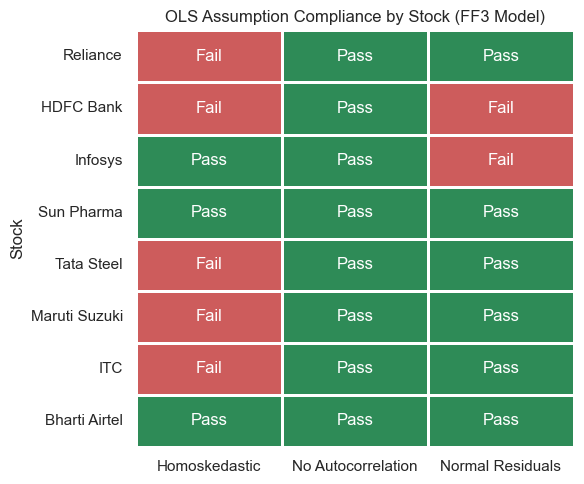

,Homoskedastic,No Autocorrelation,Normal Residuals
Stock,,,
Reliance,Fail,Pass,Pass
HDFC Bank,Fail,Pass,Fail
Infosys,Pass,Pass,Fail
Sun Pharma,Pass,Pass,Pass
Tata Steel,Fail,Pass,Pass
Maruti Suzuki,Fail,Pass,Pass
ITC,Fail,Pass,Pass
Bharti Airtel,Pass,Pass,Pass


Multicollinearity (VIF): Pass for all 8 stocks (shared regressor matrix, max VIF = 1.42)
Newey-West HAC applied to all stocks given the heteroskedasticity found above

Stocks passing all three per-stock diagnostics cleanly: ['Sun Pharma', 'Bharti Airtel']


In [20]:
# Cell 20 — Phase 5: Regression Assumption Testing | Diagnostic Summary Dashboard

from matplotlib.colors import ListedColormap

diagnostic_summary = pd.DataFrame({
    'Homoskedastic': white_summary['Heteroskedastic (5%)'].map({'Yes': 'Fail', 'No': 'Pass'}),
    'No Autocorrelation': dw_summary['Flag'].apply(lambda x: 'Pass' if x == 'No Strong Autocorrelation' else 'Fail'),
    'Normal Residuals': jb_summary['Normal Residuals (5%)'].map({'Yes': 'Pass', 'No': 'Fail'})
})

pass_matrix = (diagnostic_summary == 'Pass').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pass_matrix, annot=diagnostic_summary.values, fmt='',
            cmap=ListedColormap(['indianred', 'seagreen']),
            cbar=False, linewidths=1, linecolor='white', ax=ax)
ax.set_title('OLS Assumption Compliance by Stock (FF3 Model)')
plt.tight_layout()
plt.show()

display(diagnostic_summary)

clean_stocks = diagnostic_summary[(diagnostic_summary == 'Pass').all(axis=1)].index.tolist()
print("Multicollinearity (VIF): Pass for all 8 stocks (shared regressor matrix, max VIF = 1.42)")
print("Newey-West HAC applied to all stocks given the heteroskedasticity found above")
print(f"\nStocks passing all three per-stock diagnostics cleanly: {clean_stocks}")

Consolidates all three per-stock diagnostics into a single pass/fail heatmap, closing out Phase 5. Only Sun Pharma and Bharti Airtel pass all three tests cleanly; every other stock fails at least one — mostly White's test, since heteroskedasticity turned out to be this portfolio's dominant assumption violation, not autocorrelation or non-normality.

## Phase 6: Rolling Window Regression

A single full-period regression collapses eight years of changing market conditions into one static beta — which can hide a lot. This phase re-runs the FF3 regression on rolling 36-month windows (the standard convention for equity beta estimation) to see how each stock's factor exposures actually moved over time, especially through the COVID shock.

In [21]:
# Cell 21 — Phase 6: Rolling Window Regression | Compute Rolling FF3 Betas

window = 36
rolling_results = {}

X_full = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]

    dates, alphas, beta_mkt, beta_smb, beta_hml = [], [], [], [], []

    for i in range(window, len(y) + 1):
        y_window = y.iloc[i - window:i]
        X_window = X_full.iloc[i - window:i]
        model = sm.OLS(y_window, X_window).fit()

        dates.append(y.index[i - 1])
        alphas.append(model.params['const'])
        beta_mkt.append(model.params['MF'])
        beta_smb.append(model.params['SMB'])
        beta_hml.append(model.params['HML'])

    rolling_results[stock] = pd.DataFrame({
        'Alpha': alphas,
        'Beta_Mkt': beta_mkt,
        'Beta_SMB': beta_smb,
        'Beta_HML': beta_hml
    }, index=dates)

print(f"Rolling window: {window} months")
print(f"Rolling windows per stock: {len(rolling_results['Reliance'])}")
print(f"First window ends: {rolling_results['Reliance'].index[0].date()}")
print(f"Last window ends: {rolling_results['Reliance'].index[-1].date()}")
rolling_results['Reliance'].head()

Rolling window: 36 months
Rolling windows per stock: 96
First window ends: 2018-01-31
Last window ends: 2025-12-31


,Alpha,Beta_Mkt,Beta_SMB,Beta_HML
2018-01-31,0.0144,1.1339,-0.2596,-0.0378
2018-02-28,0.0176,1.1549,-0.2787,-0.0681
2018-03-31,0.0169,1.1758,-0.2594,-0.0608
2018-04-30,0.0151,1.2846,-0.3057,-0.1320
2018-05-31,0.0157,1.3634,-0.2964,-0.1994


### Rolling Beta Visualization

Re-runs the FF3 regression on rolling 36-month windows for each stock, using an explicit loop (rather than a pandas rolling-apply) so each multi-coefficient regression stays easy to reason about. This produces 96 rolling windows per stock, running from January 2018 through December 2025.

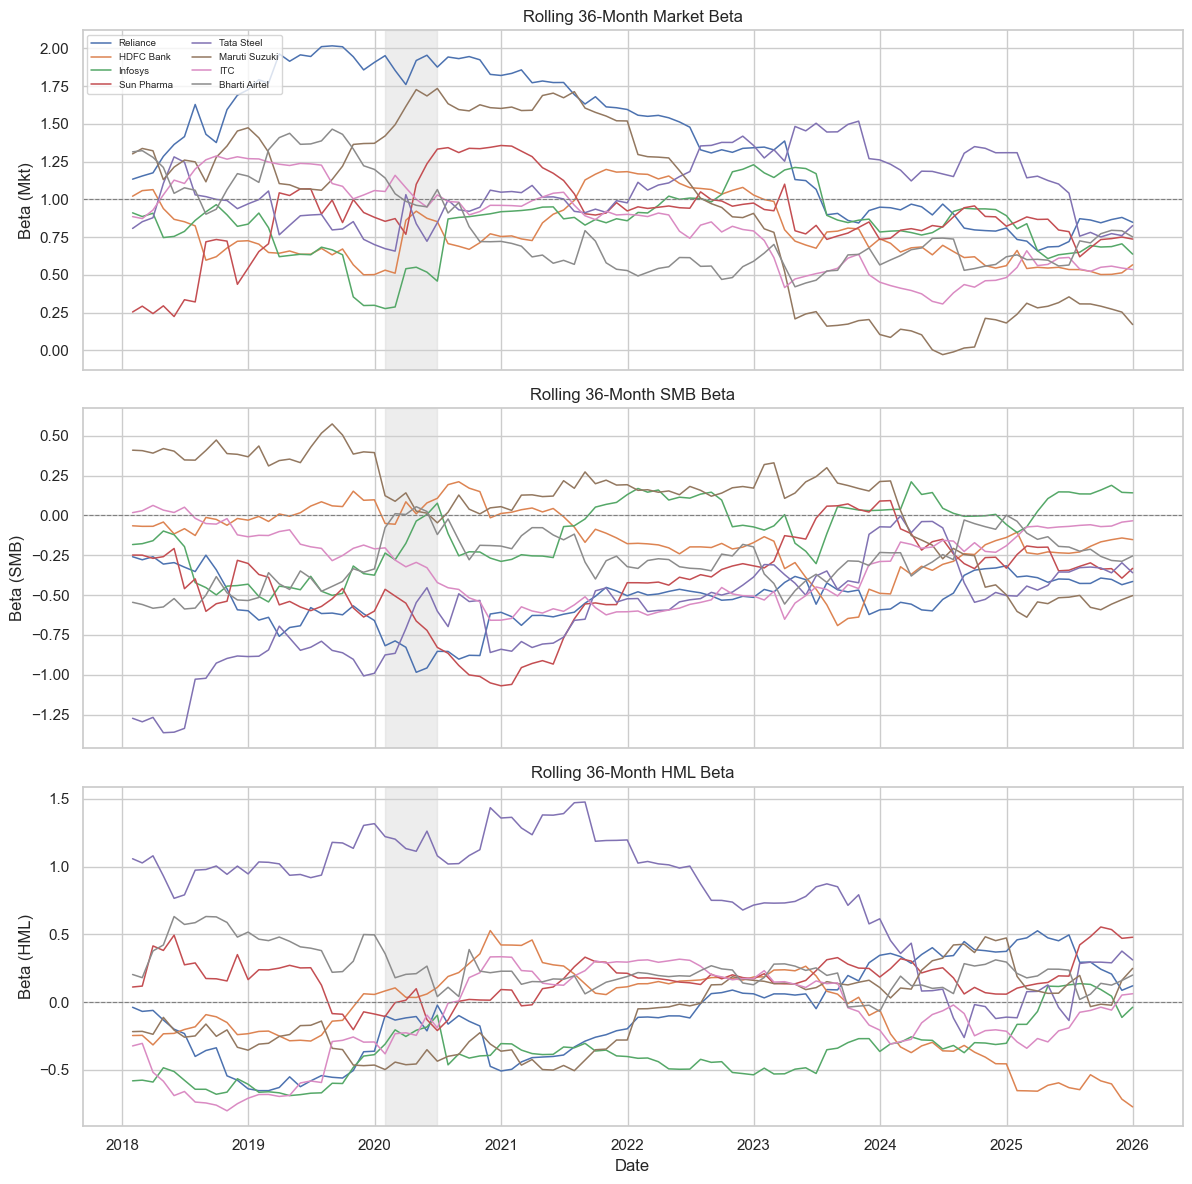

In [22]:
# Cell 22 — Phase 6: Rolling Window Regression | Rolling Beta Visualization

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for stock in excess_returns.columns:
    axes[0].plot(rolling_results[stock].index, rolling_results[stock]['Beta_Mkt'], label=stock, linewidth=1.1)
    axes[1].plot(rolling_results[stock].index, rolling_results[stock]['Beta_SMB'], label=stock, linewidth=1.1)
    axes[2].plot(rolling_results[stock].index, rolling_results[stock]['Beta_HML'], label=stock, linewidth=1.1)

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'), color='lightgray', alpha=0.4)

axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Rolling 36-Month Market Beta')
axes[0].set_ylabel('Beta (Mkt)')
axes[0].legend(loc='upper left', fontsize=7, ncol=2)

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Rolling 36-Month SMB Beta')
axes[1].set_ylabel('Beta (SMB)')

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Rolling 36-Month HML Beta')
axes[2].set_ylabel('Beta (HML)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Beta Stability Summary

Plots the rolling Market, SMB, and HML betas for all eight stocks, with the COVID crash period shaded. Reliance's market beta falls steadily from roughly 2.0 in 2018 to under 1.0 by 2022, consistent with its real diversification from a pure oil/petrochemicals cyclical into telecom (Jio) and retail. Maruti Suzuki's beta falls even further, toward zero by 2025, suggesting increasingly idiosyncratic stock-specific pressure decoupling it from broad market moves. Because these are trailing 36-month windows, the COVID crash's influence doesn't just spike and disappear — it visibly distorts the betas for roughly three years afterward, until it finally rolls out of the window.

In [23]:
# Cell 23 — Phase 6: Rolling Window Regression | Beta Stability Summary

stability_results = []

for stock in excess_returns.columns:
    r = rolling_results[stock]
    stability_results.append({
        'Stock': stock,
        'Static Beta (FF3)': ff3_summary.loc[stock, 'Beta (Mkt)'],
        'Rolling Beta Mean': r['Beta_Mkt'].mean(),
        'Rolling Beta Std': r['Beta_Mkt'].std(),
        'Rolling Beta Min': r['Beta_Mkt'].min(),
        'Rolling Beta Max': r['Beta_Mkt'].max(),
        'Beta Range': r['Beta_Mkt'].max() - r['Beta_Mkt'].min()
    })

stability_summary = pd.DataFrame(stability_results).set_index('Stock').sort_values('Rolling Beta Std', ascending=False)
display(stability_summary.round(4))

,Static Beta (FF3),Rolling Beta Mean,Rolling Beta Std,Rolling Beta Min,Rolling Beta Max,Beta Range
Stock,,,,,,
Maruti Suzuki,0.8598,0.9380,0.5938,-0.0277,1.7343,1.7619
Reliance,1.2430,1.3880,0.4351,0.6597,2.0163,1.3566
Bharti Airtel,0.8106,0.8046,0.2925,0.4213,1.4650,1.0436
ITC,0.7569,0.8240,0.2814,0.3078,1.2874,0.9796
Sun Pharma,0.8248,0.8819,0.2548,0.2246,1.3567,1.1321
Tata Steel,1.0158,1.0725,0.2217,0.6575,1.5180,0.8604
HDFC Bank,0.7886,0.7797,0.2068,0.5010,1.1984,0.6974
Infosys,0.8459,0.8268,0.2043,0.2773,1.2294,0.9521


Quantifies the beta instability visible in the chart above. Maruti Suzuki and Reliance are the two least stable stocks by rolling beta standard deviation, with Maruti's beta ranging from −0.03 to 1.73 over the sample — the same stock behaving like it has essentially zero systematic risk at one point and like a high-beta cyclical at another. Infosys is the most stable (std 0.204), narrowly ahead of HDFC Bank. Static, full-period betas can also differ from the rolling average, not just the rolling range — Reliance's static FF3 beta (1.24) sits noticeably below its rolling mean (1.39), since the single full-period regression weights all 131 months equally while the rolling mean is pulled up by how long the 2018–2020 spike lasted.

## Phase 7: CAPM vs FF3 vs Carhart Four-Factor Model Comparison

The original plan for this phase was a Fama-French five-factor comparison, but RMW and CMA don't have a maintained, citable public data source for Indian equities the way Market/SMB/HML/WML do through the IIMA library. Rather than build unreliable proxy factors for profitability and investment, I extended the comparison with the Carhart four-factor model instead — adding momentum (WML), which was already sitting in the same trusted dataset. This phase compares CAPM, FF3, and Carhart side by side, both by R² and with formal nested F-tests.

In [24]:
# Cell 24 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Run Carhart 4-Factor Regression

carhart_models = {}
carhart_results = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML', 'WML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    carhart_models[stock] = model

    carhart_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha p-value': model.pvalues['const'],
        'Beta (Mkt)': model.params['MF'],
        'Beta (SMB)': model.params['SMB'],
        'Beta (HML)': model.params['HML'],
        'Beta (WML)': model.params['WML'],
        'WML p-value': model.pvalues['WML'],
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj
    })

carhart_summary = pd.DataFrame(carhart_results).set_index('Stock')
display(carhart_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha p-value,Beta (Mkt),Beta (SMB),Beta (HML),Beta (WML),WML p-value,R-squared,Adj. R-squared
Stock,,,,,,,,,,
Reliance,0.0066,0.0791,0.2326,1.2371,-0.4717,-0.0793,-0.0903,0.4953,0.4597,0.4425
HDFC Bank,0.0088,0.1056,0.0412,0.7575,-0.0984,-0.1597,-0.4806,0.0000,0.4476,0.4300
Infosys,0.0048,0.0579,0.4162,0.8507,-0.0656,-0.3913,0.0742,0.6023,0.2321,0.2077
Sun Pharma,-0.0050,-0.0599,0.4743,0.8321,-0.3979,0.1667,0.1126,0.5009,0.2221,0.1974
Tata Steel,0.0051,0.0613,0.4889,0.9887,-0.6461,0.7765,-0.4179,0.0195,0.4767,0.4601
Maruti Suzuki,0.0098,0.1179,0.1262,0.8343,0.0688,-0.0673,-0.3949,0.0111,0.3181,0.2965
ITC,0.0024,0.0285,0.6239,0.7373,-0.1886,-0.0664,-0.3031,0.0101,0.3357,0.3146
Bharti Airtel,0.0048,0.0578,0.4192,0.8098,-0.3144,0.1943,-0.0113,0.9369,0.2911,0.2685


### Consolidated Comparison Table

Extends FF3 with momentum (WML) for all eight stocks. R² rises for every stock versus FF3, and WML comes back statistically significant for four of eight (HDFC Bank, Tata Steel, Maruti Suzuki, ITC). HDFC Bank stands out: its FF3 alpha was small and non-significant, but under Carhart its annualized alpha jumps to 10.6% and becomes significant (p = 0.041) alongside a strong negative WML loading — suggesting FF3 was misattributing a momentum-driven return pattern to alpha simply because it had no momentum factor to absorb it. HDFC Bank was also one of the five stocks flagged for heteroskedasticity in Phase 5, so a p-value this close to 0.05 from plain OLS shouldn't be treated as a final word without the same Newey-West treatment applied here.

In [25]:
# Cell 25 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Consolidated Comparison Table

model_comparison = pd.DataFrame({
    'CAPM R2': capm_summary['R-squared'],
    'FF3 R2': ff3_summary['R-squared'],
    'Carhart R2': carhart_summary['R-squared'],
    'FF3 Adj R2': ff3_summary['Adj. R-squared'],
    'Carhart Adj R2': carhart_summary['Adj. R-squared'],
    'CAPM Alpha (Ann)': capm_summary['Alpha (Annualized)'],
    'FF3 Alpha (Ann)': ff3_summary['Alpha (Annualized)'],
    'Carhart Alpha (Ann)': carhart_summary['Alpha (Annualized)'],
})

display(model_comparison.round(4))

,CAPM R2,FF3 R2,Carhart R2,FF3 Adj R2,Carhart Adj R2,CAPM Alpha (Ann),FF3 Alpha (Ann),Carhart Alpha (Ann)
Stock,,,,,,,,
Reliance,0.4001,0.4577,0.4597,0.4449,0.4425,0.0773,0.0639,0.0791
HDFC Bank,0.3482,0.3510,0.4476,0.3357,0.4300,0.0268,0.0242,0.1056
Infosys,0.1702,0.2305,0.2321,0.2123,0.2077,0.0460,0.0705,0.0579
Sun Pharma,0.1806,0.2193,0.2221,0.2008,0.1974,-0.0181,-0.0408,-0.0599
Tata Steel,0.2944,0.4535,0.4767,0.4406,0.4601,0.0720,-0.0094,0.0613
Maruti Suzuki,0.2793,0.2822,0.3181,0.2652,0.2965,0.0520,0.0511,0.1179
ITC,0.2871,0.2997,0.3357,0.2832,0.3146,-0.0144,-0.0228,0.0285
Bharti Airtel,0.2547,0.2910,0.2911,0.2743,0.2685,0.0799,0.0559,0.0578


### Nested F-Tests

Lines up R², adjusted R², and annualized alpha across all three models side by side. Adjusted R² — which penalizes factors that don't earn their place — actually falls for four of the eight stocks going from FF3 to Carhart (Reliance, Infosys, Sun Pharma, Bharti Airtel), and these are exactly the four stocks whose WML loadings weren't significant. The other four, all with significant WML, show rising adjusted R² too — a coherent pattern where momentum genuinely matters for the banking/cyclical names in this portfolio and not for IT, pharma, or telecom.

In [26]:
# Cell 26 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Nested F-Tests

from scipy import stats

f_test_results = []

for stock in excess_returns.columns:
    m_capm = capm_models[stock]
    m_ff3 = ff3_models[stock]
    m_carhart = carhart_models[stock]

    # CAPM -> FF3: joint significance of SMB and HML (q=2)
    q1 = m_ff3.df_model - m_capm.df_model
    f1 = ((m_capm.ssr - m_ff3.ssr) / q1) / (m_ff3.ssr / m_ff3.df_resid)
    p1 = stats.f.sf(f1, q1, m_ff3.df_resid)

    # FF3 -> Carhart: significance of WML (q=1)
    q2 = m_carhart.df_model - m_ff3.df_model
    f2 = ((m_ff3.ssr - m_carhart.ssr) / q2) / (m_carhart.ssr / m_carhart.df_resid)
    p2 = stats.f.sf(f2, q2, m_carhart.df_resid)

    f_test_results.append({
        'Stock': stock,
        'F (CAPM->FF3)': f1,
        'p (CAPM->FF3)': p1,
        'Sig CAPM->FF3': 'Yes' if p1 < 0.05 else 'No',
        'F (FF3->Carhart)': f2,
        'p (FF3->Carhart)': p2,
        'Sig FF3->Carhart': 'Yes' if p2 < 0.05 else 'No'
    })

f_test_summary = pd.DataFrame(f_test_results).set_index('Stock')
display(f_test_summary.round(4))

,F (CAPM->FF3),p (CAPM->FF3),Sig CAPM->FF3,F (FF3->Carhart),p (FF3->Carhart),Sig FF3->Carhart
Stock,,,,,,
Reliance,6.7380,0.0017,Yes,0.4678,0.4953,No
HDFC Bank,0.2684,0.7650,No,22.0273,0.0000,Yes
Infosys,4.9730,0.0083,Yes,0.2728,0.6023,No
Sun Pharma,3.1450,0.0464,Yes,0.4556,0.5009,No
Tata Steel,18.4820,0.0000,Yes,5.5954,0.0195,Yes
Maruti Suzuki,0.2554,0.7750,No,6.6399,0.0111,Yes
ITC,1.1402,0.3230,No,6.8291,0.0101,Yes
Bharti Airtel,3.2493,0.0420,Yes,0.0063,0.9369,No


### R-squared Comparison Chart

Formalizes the R²-based observations above with nested F-tests rather than relying on eyeballed comparisons. CAPM→FF3 is significant for five stocks but fails for HDFC Bank, Maruti Suzuki, and ITC — exactly the three stocks whose SMB and HML loadings were individually non-significant in Phase 4. FF3→Carhart is significant for the mirror-image set: HDFC Bank, Tata Steel, Maruti Suzuki, and ITC. Tata Steel is the only stock where both transitions are significant, meaning it's the single name in this portfolio genuinely exposed to size, value, and momentum simultaneously.

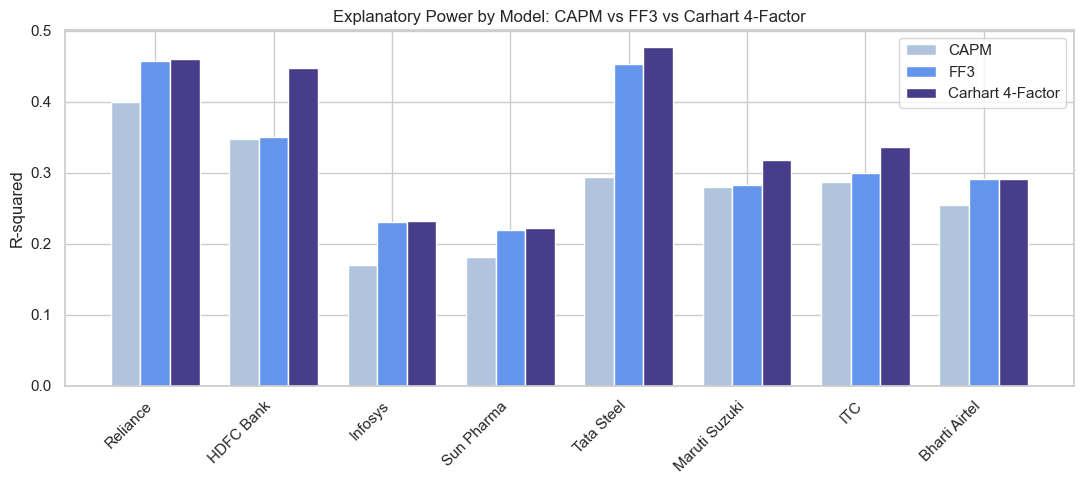

Stocks where FF3 significantly improves on CAPM: ['Reliance', 'Infosys', 'Sun Pharma', 'Tata Steel', 'Bharti Airtel']
Stocks where Carhart significantly improves on FF3: ['HDFC Bank', 'Tata Steel', 'Maruti Suzuki', 'ITC']

Stocks improved by BOTH steps: ['Tata Steel']


In [27]:
# Cell 27 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | R-squared Comparison Chart

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(model_comparison.index))
width = 0.25

ax.bar(x - width, model_comparison['CAPM R2'], width, label='CAPM', color='lightsteelblue')
ax.bar(x, model_comparison['FF3 R2'], width, label='FF3', color='cornflowerblue')
ax.bar(x + width, model_comparison['Carhart R2'], width, label='Carhart 4-Factor', color='darkslateblue')

ax.set_xticks(x)
ax.set_xticklabels(model_comparison.index, rotation=45, ha='right')
ax.set_ylabel('R-squared')
ax.set_title('Explanatory Power by Model: CAPM vs FF3 vs Carhart 4-Factor')
ax.legend()

plt.tight_layout()
plt.show()

print("Stocks where FF3 significantly improves on CAPM:", f_test_summary[f_test_summary['Sig CAPM->FF3'] == 'Yes'].index.tolist())
print("Stocks where Carhart significantly improves on FF3:", f_test_summary[f_test_summary['Sig FF3->Carhart'] == 'Yes'].index.tolist())
print("\nStocks improved by BOTH steps:", f_test_summary[(f_test_summary['Sig CAPM->FF3'] == 'Yes') & (f_test_summary['Sig FF3->Carhart'] == 'Yes')].index.tolist())

Visualizes the three-model R² comparison and confirms the F-test pattern directly in code: the stocks improved by FF3, the stocks improved by Carhart, and the stocks improved by both reduce to exactly one name — Tata Steel — closing out Phase 7.

## Phase 8: Final Dashboard

The last phase pulls the single most informative visual from each prior phase into one consolidated six-panel figure — a one-page summary of the whole project.

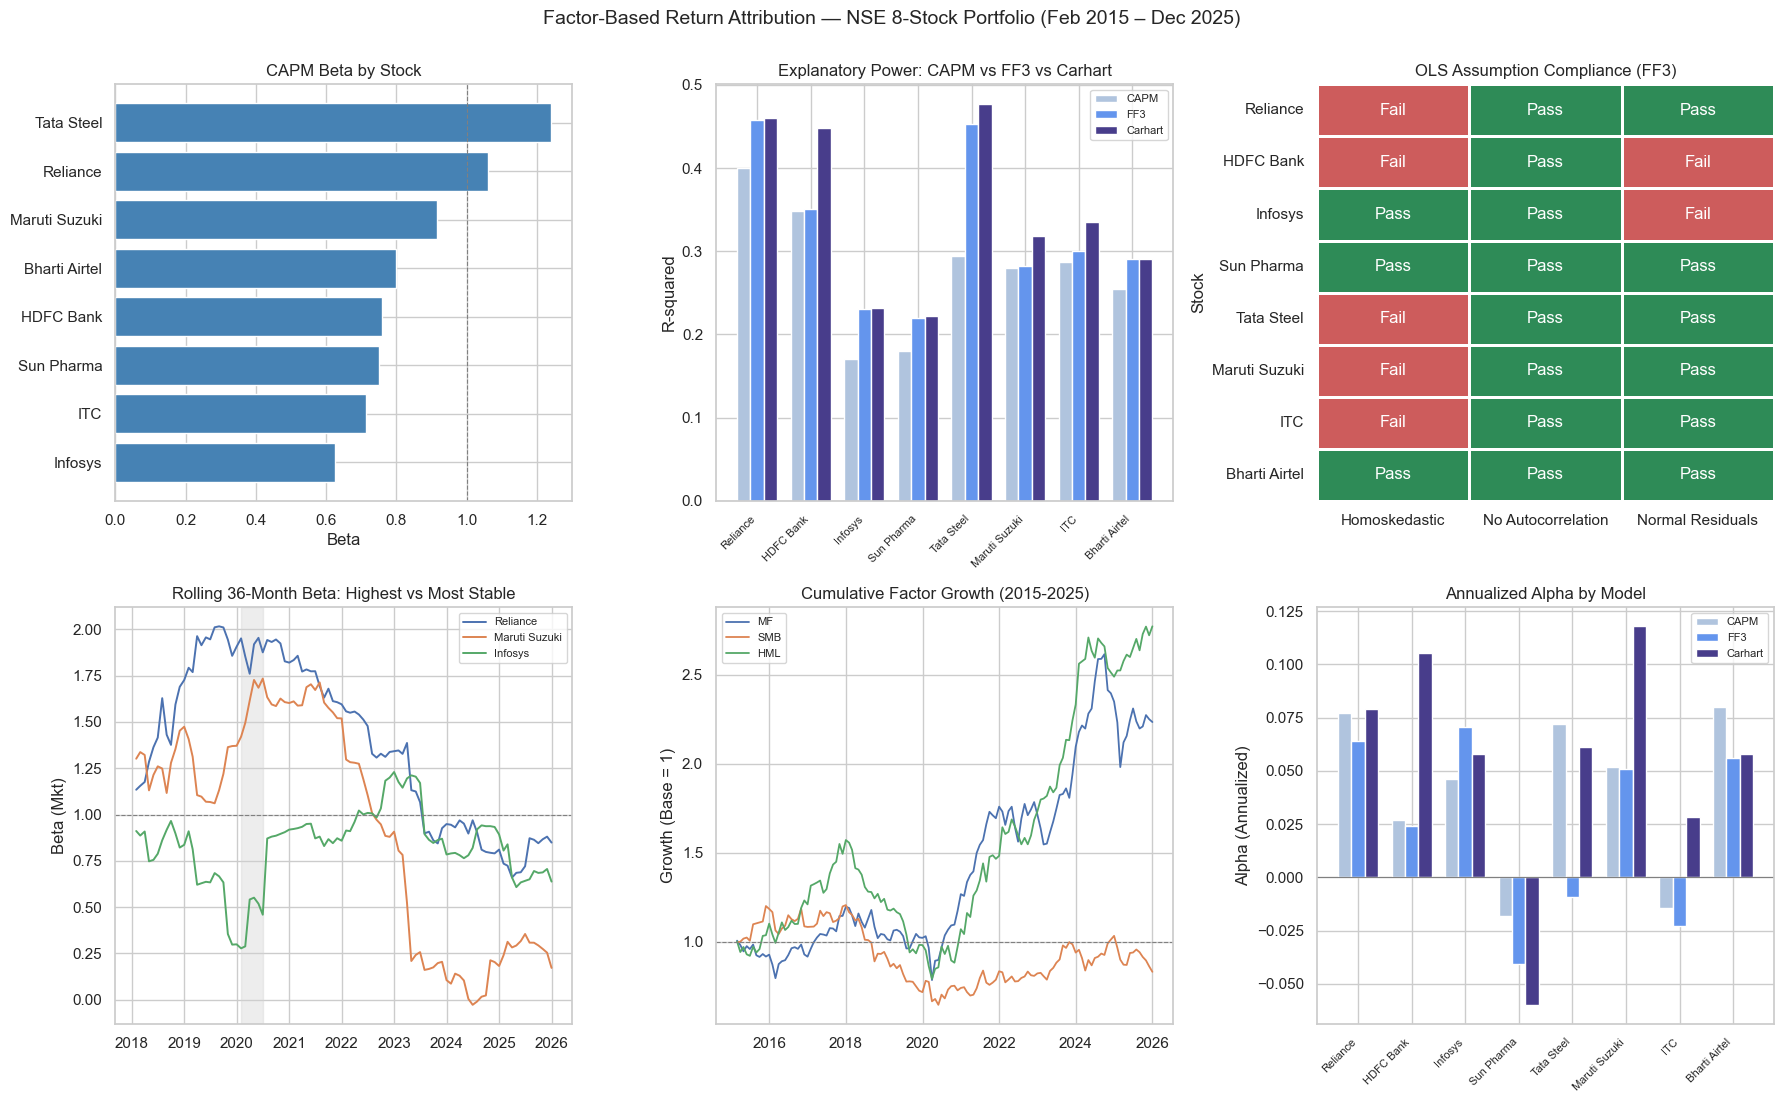

In [28]:
# Cell 28 — Phase 8: Final Dashboard | Six-Panel Project Summary Dashboard

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: CAPM Beta by stock
sorted_beta = capm_summary['Beta'].sort_values()
axes[0, 0].barh(sorted_beta.index, sorted_beta.values, color='steelblue')
axes[0, 0].axvline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('CAPM Beta by Stock')
axes[0, 0].set_xlabel('Beta')

# Panel 2: R-squared across all three models
x = np.arange(len(model_comparison.index))
width = 0.25
axes[0, 1].bar(x - width, model_comparison['CAPM R2'], width, label='CAPM', color='lightsteelblue')
axes[0, 1].bar(x, model_comparison['FF3 R2'], width, label='FF3', color='cornflowerblue')
axes[0, 1].bar(x + width, model_comparison['Carhart R2'], width, label='Carhart', color='darkslateblue')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_comparison.index, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_title('Explanatory Power: CAPM vs FF3 vs Carhart')
axes[0, 1].set_ylabel('R-squared')
axes[0, 1].legend(fontsize=8)

# Panel 3: OLS assumption compliance heatmap
pass_matrix = (diagnostic_summary == 'Pass').astype(int)
sns.heatmap(pass_matrix, annot=diagnostic_summary.values, fmt='',
            cmap=ListedColormap(['indianred', 'seagreen']),
            cbar=False, linewidths=1, linecolor='white', ax=axes[0, 2])
axes[0, 2].set_title('OLS Assumption Compliance (FF3)')

# Panel 4: Rolling market beta - most and least stable stocks
highlight_stocks = ['Reliance', 'Maruti Suzuki', 'Infosys']
for stock in highlight_stocks:
    axes[1, 0].plot(rolling_results[stock].index, rolling_results[stock]['Beta_Mkt'],
                     label=stock, linewidth=1.4)
axes[1, 0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1, 0].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'), color='lightgray', alpha=0.4)
axes[1, 0].set_title('Rolling 36-Month Beta: Highest vs Most Stable')
axes[1, 0].set_ylabel('Beta (Mkt)')
axes[1, 0].legend(fontsize=8)

# Panel 5: Cumulative factor growth
for col in ['MF', 'SMB', 'HML']:
    axes[1, 1].plot(cumulative_factors.index, cumulative_factors[col], label=col, linewidth=1.3)
axes[1, 1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1, 1].set_title('Cumulative Factor Growth (2015-2025)')
axes[1, 1].set_ylabel('Growth (Base = 1)')
axes[1, 1].legend(fontsize=8)

# Panel 6: Annualized alpha across models
axes[1, 2].bar(x - width, model_comparison['CAPM Alpha (Ann)'], width, label='CAPM', color='lightsteelblue')
axes[1, 2].bar(x, model_comparison['FF3 Alpha (Ann)'], width, label='FF3', color='cornflowerblue')
axes[1, 2].bar(x + width, model_comparison['Carhart Alpha (Ann)'], width, label='Carhart', color='darkslateblue')
axes[1, 2].axhline(0, color='gray', linewidth=0.8)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(model_comparison.index, rotation=45, ha='right', fontsize=8)
axes[1, 2].set_title('Annualized Alpha by Model')
axes[1, 2].set_ylabel('Alpha (Annualized)')
axes[1, 2].legend(fontsize=8)

plt.suptitle('Factor-Based Return Attribution — NSE 8-Stock Portfolio (Feb 2015 – Dec 2025)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Six-panel summary pulling the single most informative chart from each prior phase into one consolidated figure: CAPM betas, R² across all three models, OLS assumption compliance, rolling beta stability for the highest and most stable stocks, cumulative factor growth, and annualized alpha across models. This is the one visual meant to represent the whole project at a glance.

## Key Findings and Conclusion

This project set out to move beyond a single static CAPM beta and actually test how much of an Indian large-cap stock's return can be attributed to systematic risk factors — and how much of that attribution survives real econometric scrutiny.

**On model comparison:** Adding size and value (FF3) meaningfully improved on CAPM for five of the eight stocks, most notably Tata Steel, Reliance, and Infosys — but did essentially nothing for HDFC Bank, Maruti Suzuki, or ITC. Adding momentum (Carhart) picked up almost exactly where FF3 left off, improving those same three "unexplained" stocks, plus Tata Steel again. Only Tata Steel showed significant exposure to size, value, *and* momentum simultaneously — every other stock in this portfolio is explained by some subset of these factors, not all of them. That's arguably the single most useful takeaway of the whole notebook: there's no one model that fits every stock, and knowing which factors matter for which names is more informative than picking a "best" model and applying it uniformly.

**On robustness:** Five of the eight stocks failed White's test for heteroskedasticity, but Newey-West correction confirmed every significant SMB, HML, and WML finding held up under HAC standard errors — the factor relationships in this portfolio aren't an artifact of understated OLS variance. Autocorrelation, by contrast, was essentially a non-issue at monthly frequency across all eight stocks.

**On beta stability:** The single biggest limitation of every static regression in this notebook is visible in the rolling window results — Reliance's market beta more than halved over the sample period as the company diversified beyond oil and petrochemicals, and Maruti Suzuki's beta ranged from near-zero to 1.73 depending on the window. A single full-period beta, the kind that shows up in a typical equity research note, can misrepresent a stock's actual risk profile by a wide margin depending on when it's measured.

**On data sourcing:** Market, SMB, HML, and WML were sourced from the Fama-French and Momentum factor library maintained by IIM Ahmedabad (Agarwalla, Jacob & Varma, 2013) rather than self-constructed from free data — genuine size, value, and momentum sorts require point-in-time market cap and book value data across a broad universe that isn't reliably available through free tools like yfinance, and using current fundamentals to build a historical factor would introduce look-ahead bias. This is also why the original Fama-French five-factor comparison was scoped down to a Carhart four-factor comparison instead: RMW and CMA don't have an equivalent maintained, citable data source for Indian equities, and a real, defensible four-factor model is a stronger foundation than an unreliable five-factor proxy.

For a project built around market risk and model validation, the more interesting result here isn't that the factor models "worked" — it's *where* they didn't, and being able to explain why.